## Install libraries and packages

In [1]:
#Install packages into kernel's enviornment
%pip install seaborn scikit-learn
%pip install -e '../../decipher-bc'


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///Users/alanxie/CodingProjects/Columbia/Azizi%20Lab/Spatial%20Nut%20Carcinoma/decipher-bc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scdecipher (pyproject.toml) ... done
  Created wheel for scdecipher: filename=scdecipher-0.1.3-py3-none-any.whl size=2193 sha256=a083d111b7757fd42c95b1c711ba62e2d1ae21b110921676f57fa3e48194b60f
  Stored in directory: /private/var/folders/3p/7nndjfj95j1b_fk0h38c9_y80000gn/T/pip-ephem-wheel-cache-eu4wx1rt/wheels/ea/06/26/26159dbfb6aa8149e61b1400ecea7c99526e36bf7872679e1e
Successfully built scdecipher
  Attempting uninstall: scdecipher
    Found existing installation: scdecipher 0.

In [2]:
#Import libraries and packages
import os
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import logging
from scipy.stats import spearmanr

In [3]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore")

In [4]:
# Import the new package name
import decipher as dc
dc.pl.activate_journal_quality()

In [5]:
# Import batch correction models
sys.path.insert(0, '..')   # adds decipher-bc-methods/ to path

import importlib
avzx = importlib.import_module('attention-v-z-x')   # avzx.tl.decipher_train(...)
cvtz = importlib.import_module('concat-v-to-z')     # cvtz.tl.decipher_train(...)

## Generate simulated data (v2 — linear trajectory)

Uses `sim_data_gen_v2_ax/simulation_functions.py`.

Generative process per batch:
```
latent_t         ~ Uniform[0, 1]
z_mu              = latent_t                     # 1D, no branching
shifted_z_mu      = z_mu + shift_z               # batch shift as bias
latent_z_sampled ~ N(shifted_z_mu, sigma)        # add noise
adata.X           = clip(latent_z_sampled @ W, 0) # linear decode
```

In [6]:
# Add sim_data_gen_v2_ax to path so we can import simulation_functions directly
sys.path.insert(0, '../Data/Simulated Data/sim_data_gen_v2_ax')
from simulation_functions import simulation_linear_trajectory

# Parameters
N_SAMPLES = 500
N_GENES   = 50
SEED      = 0
SIGMA     = 0.03
SHIFTS    = [0.0, 0.12, 0.24, 0.36]   # shift_z values per batch (0.0 = unshifted base)

# Generate one adata per shift, then concatenate
# seed=SEED + i gives each batch an independent latent_t sample — avoids all batches
# having identical pseudotime positions (same seed → same Uniform[0,1] draw → sparse embedding)
adatas = []
for i, s in enumerate(SHIFTS):
    a = simulation_linear_trajectory(
        n_samples=N_SAMPLES,
        n_genes=N_GENES,
        seed=SEED + i,
        sigma=SIGMA,
        shift_z=s,
    )
    # Convert shift_z to string so scanpy can use it as a categorical color key
    a.obs["shift_z"] = str(s)
    adatas.append(a)

adata = ad.concat(adatas, axis=0, join="outer", label=None, merge="same")
adata.obs_names_make_unique()
adata.uns["color_palette"] = None

print(adata)
print("shift_z unique values:", adata.obs["shift_z"].unique().tolist())

AnnData object with n_obs × n_vars = 2000 × 50
    obs: 'latent_t', 'shift_z'
    uns: 'color_palette'
    obsm: 'latent_z_mu', 'shifted_latent_z_mu', 'latent_z_sampled'
shift_z unique values: ['0.0', '0.12', '0.24', '0.36']


## Run native decipher on simulated data

Epoch 182 (batch 28/28) | | train elbo: 66.70 (last epoch: 66.31) | val ll: 75.00:  18%|█▊        | 182/1000 [00:26<01:59,  6.86it/s]2026-06-26 14:49:09,128 | INFO : Early stopping has been triggered.
2026-06-26 14:49:09,130 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 14:49:09,130 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 14:49:09,132 | INFO : Saving decipher model with run_id 2026-06-26-14-49-09-plain-wary-chimichanga.


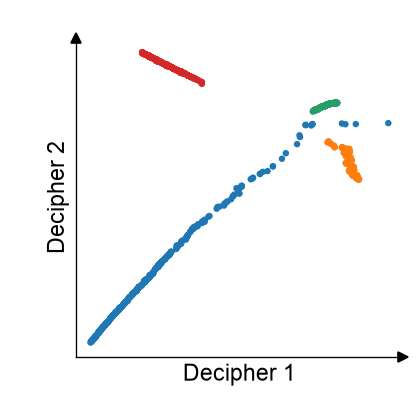

... storing 'shift_z' as categorical


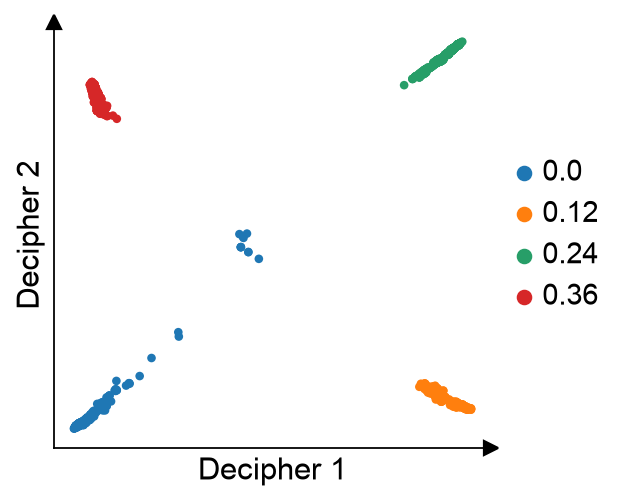

In [7]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

adata_native = adata.copy()
d_native, val_native = dc.tl.decipher_train(
    adata_native, decipher_config, plot_kwargs={"color": "shift_z"},
    plot_every_k_epochs=5,
)

... storing 'shift_z' as categorical


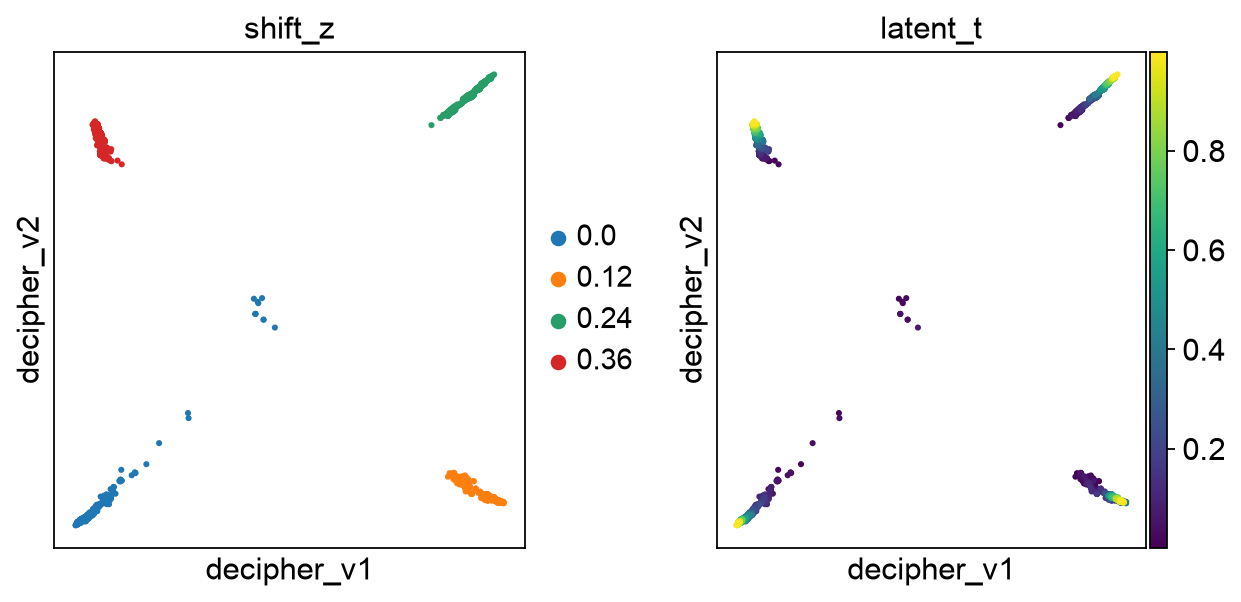

In [8]:
# Plot decipher_v colored by shift_z and latent_t
# REMOVED: cluster_true column (no branching in v2 → no ground-truth clusters)
# REPLACED WITH: latent_t (ground-truth pseudotime) as the biological reference
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_native, basis="decipher_v", color="shift_z",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_native, basis="decipher_v", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

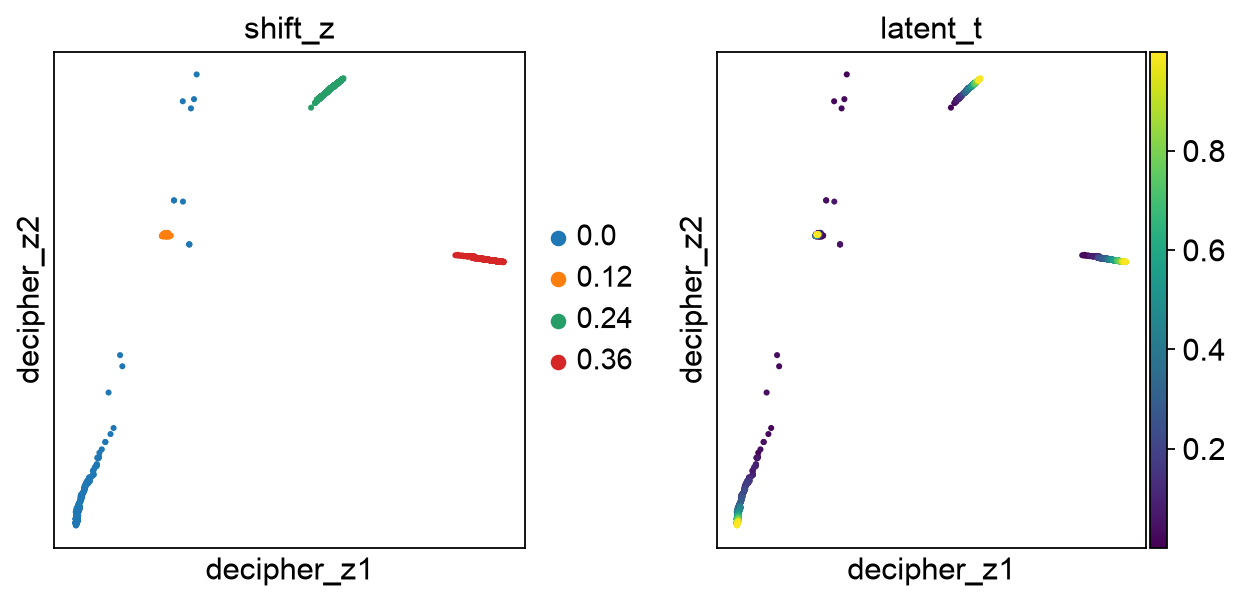

In [9]:
# decipher_z: no batch correction — baseline showing batch is still visible in z.
# Compare against avzx's decipher_z below; shift_z should be less separated there.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_native, basis="decipher_z", color="shift_z",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_native, basis="decipher_z", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

In [10]:
# REMOVED: ARI (adjusted_rand_score) vs cluster_true — no ground-truth clusters in v2
# REPLACED WITH: Spearman correlation of decipher_v[:,0] vs latent_t
#   Higher correlation = model recovers the true pseudotime ordering

v_native = adata_native.obsm["decipher_v"]

print("── Spearman correlation: decipher_v vs latent_t (per shift_z) ──────────")
for s in sorted(adata_native.obs["shift_z"].unique()):
    mask = adata_native.obs["shift_z"] == s
    rho, pval = spearmanr(v_native[mask, 0], adata_native.obs["latent_t"][mask])
    print(f"  shift_z={s:<6}  rho={rho:+.4f}  p={pval:.2e}")

── Spearman correlation: decipher_v vs latent_t (per shift_z) ──────────
  shift_z=0.0     rho=-0.9637  p=7.98e-288
  shift_z=0.12    rho=+0.7627  p=2.58e-96
  shift_z=0.24    rho=+0.9776  p=0.00e+00
  shift_z=0.36    rho=-0.8457  p=5.96e-138


In [11]:
from sklearn.metrics import silhouette_score

v = adata_native.obsm["decipher_v"].copy()
labels = adata_native.obs["shift_z"].astype(str)

print("── Silhouette score in v-space (higher = stronger batch separation) ─────")
score = silhouette_score(v, labels, sample_size=5000, random_state=42)
print(f"  shift_z  silhouette = {score:.4f}")

── Silhouette score in v-space (higher = stronger batch separation) ─────
  shift_z  silhouette = 0.9501


## Run attention-v-z-x on simulated data

Epoch 999 (batch 28/28) | | train elbo: 71.20 (last epoch: 69.63) | val ll: 80.06: 100%|██████████| 1000/1000 [02:21<00:00,  7.06it/s]2026-06-26 14:51:31,499 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 14:51:31,499 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 14:51:31,500 | INFO : Saving decipher model with run_id 2026-06-26-14-51-31-finite-corn-wok.


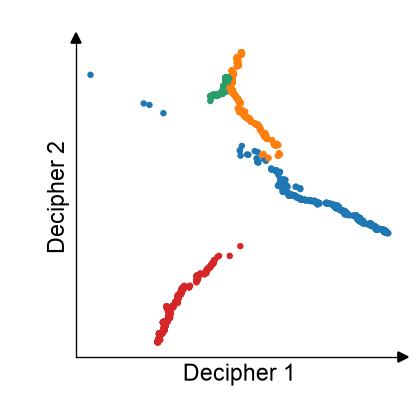

... storing 'shift_z' as categorical


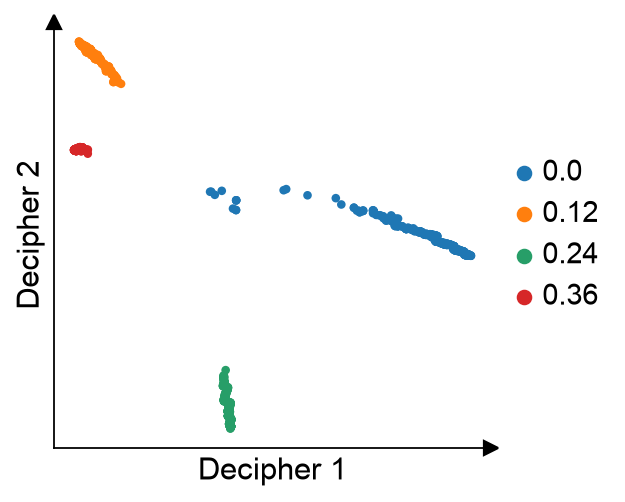

In [12]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-4, seed=1, early_stopping_patience=50)

adata_avzx = adata.copy()
d_avzx, val_avzx = avzx.tl.decipher_train(
    adata_avzx, decipher_config, plot_kwargs={"color": "shift_z"},
    batch_key="shift_z",
    plot_every_k_epochs=5,
)

... storing 'shift_z' as categorical


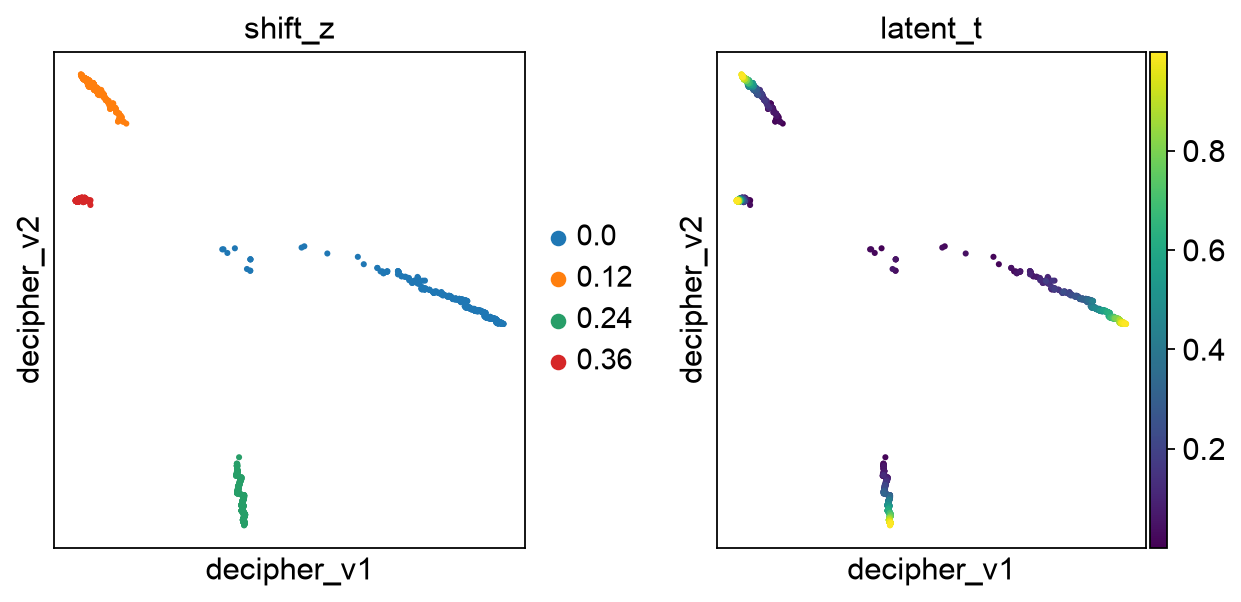

In [13]:
# Plot decipher_v — shift_z groups should still be visible here (v captures biology + batch)
# REMOVED: cluster_true column (no branching in v2)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_avzx, basis="decipher_v", color="shift_z",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_v", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

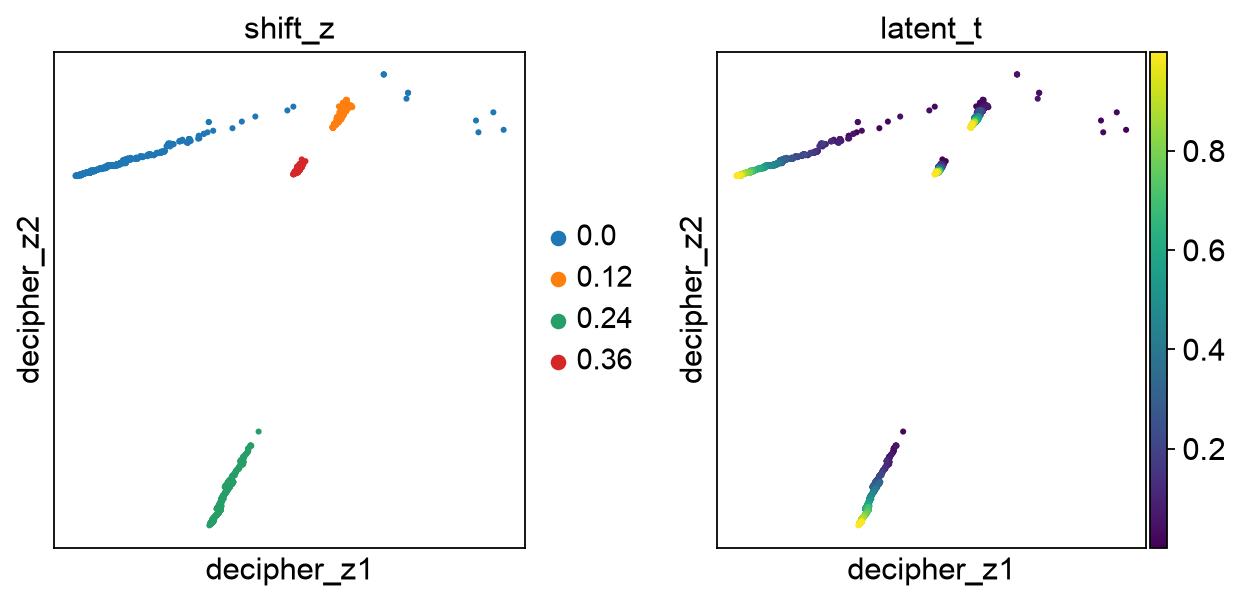

In [14]:
# Plot decipher_z — this is where attention-v-z-x applies batch correction.
# Shift groups should be less separated here if the model is working.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_avzx, basis="decipher_z", color="shift_z",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_z", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

In [15]:
# Spearman correlation: does avzx recover latent_t better than native decipher?
v_avzx = adata_avzx.obsm["decipher_v"]

print("── Spearman correlation: decipher_v vs latent_t (per shift_z) ──────────")
for s in sorted(adata_avzx.obs["shift_z"].unique()):
    mask = adata_avzx.obs["shift_z"] == s
    rho, pval = spearmanr(v_avzx[mask, 0], adata_avzx.obs["latent_t"][mask])
    print(f"  shift_z={s:<6}  rho={rho:+.4f}  p={pval:.2e}")

── Spearman correlation: decipher_v vs latent_t (per shift_z) ──────────
  shift_z=0.0     rho=+0.9944  p=0.00e+00
  shift_z=0.12    rho=-0.9730  p=0.00e+00
  shift_z=0.24    rho=+0.7858  p=5.54e-106
  shift_z=0.36    rho=-0.9630  p=8.11e-286


In [16]:
from sklearn.metrics import silhouette_score

v = adata_avzx.obsm["decipher_v"].copy()
labels = adata_avzx.obs["shift_z"].astype(str)

print("── Silhouette score in v-space (lower = better batch correction) ────────")
score = silhouette_score(v, labels, sample_size=5000, random_state=42)
print(f"  shift_z  silhouette = {score:.4f}")

── Silhouette score in v-space (lower = better batch correction) ────────
  shift_z  silhouette = 0.9073
